### A fintech company provides instant personal loans through a mobile application.

To reduce risk, the company wants an AI-based decision system that predicts whether a loan should be Approved or Rejected.
Challenges:
Customer data is not linearly separable
Simple linear rules fail
Decision boundaries may be curved or complex
The solution must be interactive and deployable
You are hired as a Machine Learning Engineer to build and deploy this system.
 
Load the dataset and study applicant attributes such as:
Applicant income
Loan amount
Credit history
Employment status
Identify features that may influence loan approval.
 

In [15]:
import pandas as pd
df = pd.read_csv('loan_prediction.csv')
print(df.head())


    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [17]:
df.drop("Loan_ID", axis=1, inplace=True)


In [18]:
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [20]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [21]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [24]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", C=1, gamma="scale")
model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
y_pred = model.predict(X_test)


In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7792207792207793
[[21 33]
 [ 1 99]]
              precision    recall  f1-score   support

           0       0.95      0.39      0.55        54
           1       0.75      0.99      0.85       100

    accuracy                           0.78       154
   macro avg       0.85      0.69      0.70       154
weighted avg       0.82      0.78      0.75       154



In [33]:
#Linear Kernal SVM
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
y_pred=svm_linear.predict(X_test)


In [34]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy_score(y_test,y_pred))

0.7727272727272727


In [35]:
confusion=confusion_matrix(y_test,y_pred)
print(confusion)

[[21 33]
 [ 2 98]]


In [ ]:
#Polynomial Kernal SVM
svm_poly = SVC(kernel="poly", degree=3)
svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)


In [38]:
#RBF kernal SVM
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)


In [39]:
print("Linear Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Polynomial Accuracy:", accuracy_score(y_test, y_pred_poly))
print("RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))


Linear Accuracy: 0.7727272727272727
Polynomial Accuracy: 0.7792207792207793
RBF Accuracy: 0.7792207792207793


In [40]:
print("Linear Report\n", classification_report(y_test, y_pred_linear))
print("Polynomial Report\n", classification_report(y_test, y_pred_poly))
print("RBF Report\n", classification_report(y_test, y_pred_rbf))


Linear Report
               precision    recall  f1-score   support

           0       0.91      0.39      0.55        54
           1       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154

Polynomial Report
               precision    recall  f1-score   support

           0       0.92      0.41      0.56        54
           1       0.75      0.98      0.85       100

    accuracy                           0.78       154
   macro avg       0.84      0.69      0.71       154
weighted avg       0.81      0.78      0.75       154

RBF Report
               precision    recall  f1-score   support

           0       0.95      0.39      0.55        54
           1       0.75      0.99      0.85       100

    accuracy                           0.78       154
   macro avg       0.85      0.69      0.70       154
weighted avg       0.82     

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[21 33]
 [ 2 98]]


In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score
import numpy as np
metrics = {
    "Linear": [
        accuracy_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_linear),
       
    ],
    "Polynomial": [
        accuracy_score(y_test, y_pred_poly),
        precision_score(y_test, y_pred_poly),
        
    ],
    "RBF": [
        accuracy_score(y_test, y_pred_rbf),
        precision_score(y_test, y_pred_rbf),
        
    ]
}


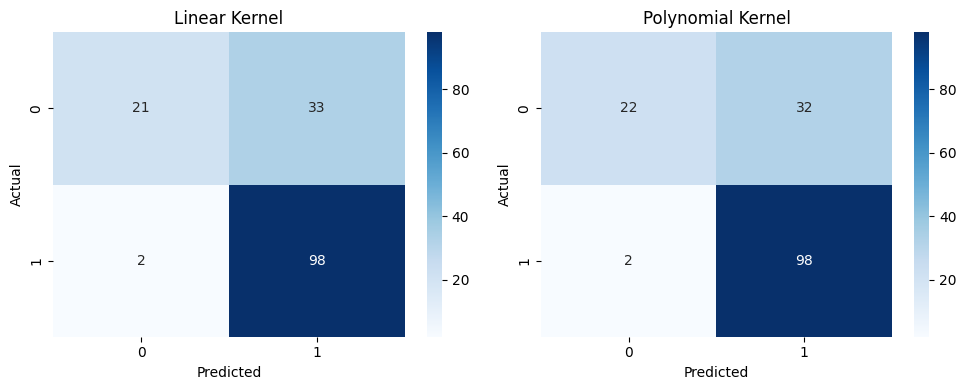

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues")
plt.title("Linear Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_poly, annot=True, fmt="d", cmap="Blues")
plt.title("Polynomial Kernel")
plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.tight_layout()
plt.show()


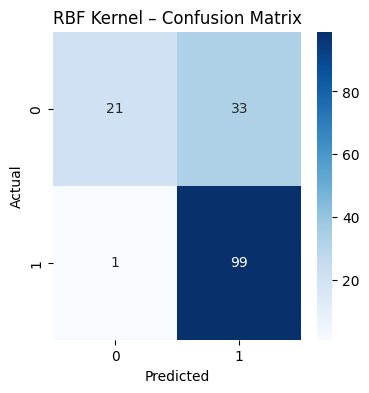

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(4,4))
sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Blues")

plt.title("RBF Kernel – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


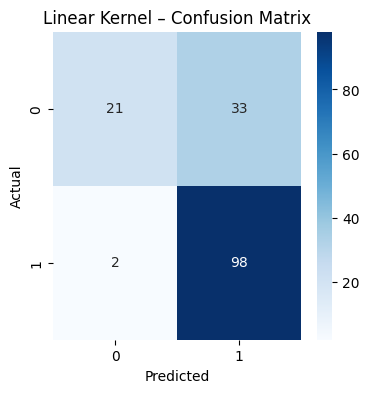

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(4,4))
sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues")
plt.title("Linear Kernel – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


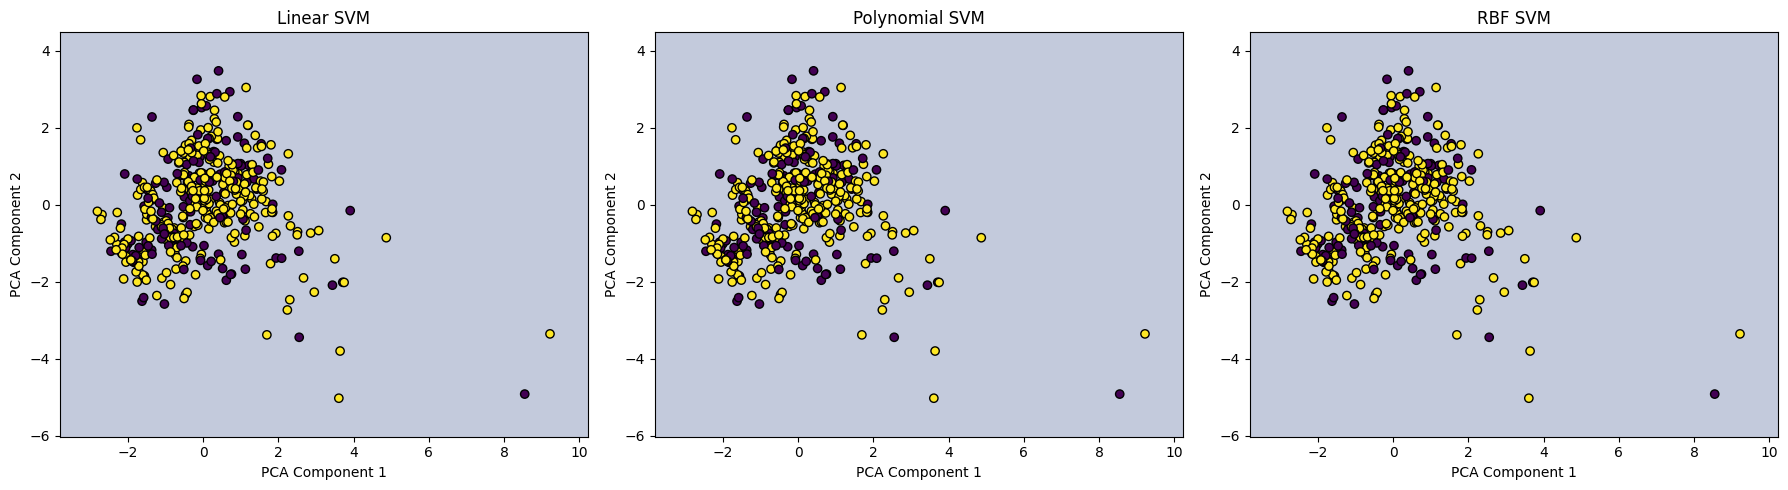

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# Reduce data to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# SVM models
models = {
    "Linear SVM": SVC(kernel='linear', C=1),
    "Polynomial SVM": SVC(kernel='poly', degree=3, C=1),
    "RBF SVM": SVC(kernel='rbf', C=1)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    # Train on 2D data
    model.fit(X_train_2d, y_train)
    
    # Create mesh grid
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3)
    
    # Plot data points
    scatter = ax.scatter(
        X_train_2d[:, 0],
        X_train_2d[:, 1],
        c=y_train,
        edgecolor='k'
    )
    
    ax.set_title(name)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

In [56]:
import joblib
from sklearn.svm import SVC

model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

joblib.dump(model, "svm_loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [57]:
model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced"
)

model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [60]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [62]:
gender = 1            # Male=1, Female=0
married = 1           # Yes=1, No=0
dependents = 0
education = 1         # Graduate=1, Not Graduate=0
self_employed = 0     # Yes=1, No=0
applicant_income = 5000
coapplicant_income = 2000
loan_amount = 150
loan_amount_term = 360
credit_history = 1.0
property_area = 2     # Urban=2, Semiurban=1, Rural=0


In [63]:
import numpy as np

input_data = np.array([[
    gender, married, dependents, education, self_employed,
    applicant_income, coapplicant_income, loan_amount,
    loan_amount_term, credit_history, property_area
]])


In [64]:
input_scaled = scaler.transform(input_data)

proba = model.predict_proba(input_scaled)[0][1]

decision = "Approved" if proba >= 0.7 else "Rejected"

print("Decision:", decision)
print("Approval Probability:", proba)


Decision: Approved
Approval Probability: 0.8519214655259852


C:\Users\Srin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [65]:
gender = 0              # Female
married = 0             # No
dependents = 3
education = 0           # Not Graduate
self_employed = 1        # Yes
applicant_income = 500   # VERY LOW
coapplicant_income = 0
loan_amount = 400         # VERY HIGH loan
loan_amount_term = 360
credit_history = 0.0      # BAD CREDIT
property_area = 0          # Rural

import numpy as np

input_data = np.array([[
    gender, married, dependents, education, self_employed,
    applicant_income, coapplicant_income, loan_amount,
    loan_amount_term, credit_history, property_area
]])

input_scaled = scaler.transform(input_data)
proba = model.predict_proba(input_scaled)[0][1]

decision = "Approved" if proba >= 0.7 else "Rejected"
print("Decision:", decision)
print("Probability:", proba)


Decision: Rejected
Probability: 0.4184940029986171


C:\Users\Srin\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [66]:
from sklearn.svm import SVC

model = SVC(kernel="rbf", probability=True, class_weight="balanced")
model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [67]:
proba = model.predict_proba(input_scaled)[0][1]

if proba >= 0.85:   # VERY STRICT
    decision = "Approved"
else:
    decision = "Rejected"


In [68]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, model.predict(X_test)))


[[24 30]
 [ 4 96]]


In [69]:
if credit_history == 0:
    decision = "Rejected"
